## Random Forest Overfitting - When Do Random Forests Overfit?

#### Sujin Park, Maseeh Department of Civil, Architectural and Environmental Engineering, The University of Texas at Austin

### Subsurface Machine Learning Course, The University of Texas at Austin




_____________________

Workflow supervision and review by:

#### Instructor: Prof. Michael Pyrcz, Ph.D., P.Eng., Professor, The Univeristy of Texas at Austin
##### [Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)

#### Course TA: Maria Gonzalez, Graduate Student, The University of Texas at Austin

### Executive Summary

In this study, it is demonstrated that Random Forest models can exhibit overfitting under certain hyperparameter configurations, despite their recognized robustness achieved through bagging and feature subsampling. An open, synthetic classification dataset was generated, and two model configurations were compared: an overfitted Random Forest characterized by deep, highly correlated trees, and a regularized Random Forest employing bootstrap sampling, feature subsampling, and depth constraints. Training, validation, and testing performances were visualized, along with a validation curve as a function of tree depth. The results indicate that disabling randomization and permitting unrestricted tree growth lead to perfect training accuracy but deteriorated test performance, whereas moderate regularization restores generalization capability. This workflow was designed to be fully reproducible and serves as an educational demonstration of how model capacity and randomization govern the bias–variance tradeoff in ensemble learning methods.

### Introduction

Random Forest is a widely used and versatile supervised machine learning algorithm capable of handling both classification and regression tasks. The method constructs an ensemble of decision trees, each trained on a bootstrap sample of the data and using a randomly selected subset of features at each split. These sources of randomness, bagging for data resampling and feature subsampling for decorrelating trees, form the core mechanisms that typically reduce overfitting and improve predictive stability compared to individual decision trees. Predictions are obtained by aggregating the outputs of all trees, through majority voting in classification or averaging in regression.

Although Random Forests are generally regarded as robust models, they can still overfit when the ensemble’s built-in randomization is reduced or when tree capacity is allowed to grow unrestricted. Situations such as disabling bootstrapping, using all features at each split, or permitting trees to grow very deep can produce highly correlated and overly complex trees that memorize the training data. As a result, Random Forests may exhibit perfect or near-perfect training accuracy while suffering degraded performance on validation or test sets. 

This study examines these conditions explicitly by comparing intentionally overfitted configurations with regularized alternatives, demonstrating how randomness and model capacity govern the bias–variance tradeoff and influence generalization performance.

### Importing Packages

In this section, the Python packages required for data generation, model training, evaluation, and visualization are imported.

In [6]:
# NOTE: Portions of this cell are adapted from MachineLearning_ensemble_trees.ipynb
%matplotlib inline                                         
suppress_warnings = True

import os                                                     # to set current working directory 
import math                                                   # square root operator
import time                                                   # to measure execution time
import numpy as np                                            # arrays and matrix math
import scipy.stats as st                                      # statistical methods
import pandas as pd                                           # DataFrames
import matplotlib.pyplot as plt                               # for plotting
from matplotlib.ticker import (MultipleLocator,AutoMinorLocator,FuncFormatter) # control of axes ticks
from matplotlib.colors import ListedColormap                  # custom color maps
import seaborn as sns                                         # visualization

from sklearn.datasets import make_classification              # synthetic classification data
from sklearn.model_selection import train_test_split          # train/valid/test split
from sklearn.ensemble import RandomForestClassifier           # random forest classifier
from sklearn.metrics import accuracy_score, f1_score          # evaluation metrics

RANDOM_STATE = 0                                              # global random seed
os.makedirs('results', exist_ok=True)                         # output directory

### Loading / Generating the Data

A synthetic binary classification dataset with 8,000 samples and 100 features—15 informative and 10 redundant—is generated using sklearn.datasets.make_classification. To accentuate overfitting behavior, 15% label noise (flip_y = 0.15) is introduced. The dataset is then partitioned into 60% training, 20% validation, and 20% test subsets using stratified sampling.

In [7]:
X, y = make_classification(n_samples=8000, n_features=100, n_informative=15, n_redundant=10,
                           flip_y=0.15, random_state=RANDOM_STATE)
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE)
X_va, X_te, y_va, y_te = train_test_split(X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=RANDOM_STATE)
print(f'Train: {X_tr.shape}, Valid: {X_va.shape}, Test: {X_te.shape}')

Train: (4800, 100), Valid: (1600, 100), Test: (1600, 100)


### Functions

A helper function, run_rf, is subsequently defined to train a Random Forest under a specified set of hyperparameters and to compute key performance metrics on the training, validation, and test subsets, along with the out-of-bag (OOB) score when bootstrapping is activated. This encapsulated function enables efficient evaluation of multiple model configurations and facilitates extensibility of the overall workflow.

In [8]:
def run_rf(params, X_tr, y_tr, X_va, y_va, X_te, y_te, seed=0):
    rf = RandomForestClassifier(
        n_estimators=params.get('n_estimators', 200),
        bootstrap=params.get('bootstrap', True),
        max_features=params.get('max_features', 'sqrt'),
        max_depth=params.get('max_depth', None),
        min_samples_leaf=params.get('min_samples_leaf', 1),
        random_state=seed, n_jobs=-1,
        oob_score=params.get('bootstrap', True)
    )
    t0 = time.time()
    rf.fit(X_tr, y_tr)
    fit_time = time.time() - t0

    pred_tr = rf.predict(X_tr)
    pred_va = rf.predict(X_va)
    pred_te = rf.predict(X_te)

    metrics = {
        'train_acc': accuracy_score(y_tr, pred_tr),
        'valid_acc': accuracy_score(y_va, pred_va),
        'test_acc': accuracy_score(y_te, pred_te),
        'train_f1': f1_score(y_tr, pred_tr, average='macro'),
        'valid_f1': f1_score(y_va, pred_va, average='macro'),
        'test_f1': f1_score(y_te, pred_te, average='macro'),
        'oob_score': getattr(rf, 'oob_score_', np.nan),
        'fit_time_sec': fit_time
    }
    return metrics

### Workflow Overview

The analysis consists of three main steps:

1. **Compare Overfit vs Regularized Configurations**  
   Two Random Forest setups are specified and evaluated to illustrate the train–test performance gap under overfitting and the improved generalization     achieved through regularization.

2. **Train and Evaluate Models**  
   Both configurations are executed, and accuracy and F1 scores are computed on the training, validation, and test subsets, with out-of-bag (OOB)          scores reported when applicable.

3. **Explore the Effect of Tree Depth**  
   A sweep over `max_depth` values is performed to construct a validation curve, demonstrating how increasing model capacity can eventually degrade          generalization performance.

### Step 1. Overfit vs Regularized Random Forest Configurations

Two model configurations are defined for comparison:

- **Overfit**: deep trees (`max_depth=None`), no bootstrapping (`bootstrap=False`), and use of all features at each split (`max_features=1.0`). This      setup encourages highly correlated trees with high capacity,
  which can memorize the training data.
- **Regularized**: bootstrapping enabled, feature subsampling (`max_features='sqrt'`), limited depth (`max_depth=12`), and a minimum leaf size of 10      samples. This configuration controls variance and improves generalization.

In [9]:
configs = {
    'Overfit': dict(bootstrap=False, max_features=1.0, max_depth=None, min_samples_leaf=1, n_estimators=200),
    'Regularized': dict(bootstrap=True, max_features='sqrt', max_depth=12, min_samples_leaf=10, n_estimators=200)
}

rows = []
for label, params in configs.items():
    metrics = run_rf(params, X_tr, y_tr, X_va, y_va, X_te, y_te)
    metrics.update(params)
    metrics['config'] = label
    rows.append(metrics)
    print(label, {k: round(metrics[k], 3) for k in ['train_acc', 'valid_acc', 'test_acc', 'oob_score']})

df = pd.DataFrame(rows)
df

Overfit {'train_acc': 1.0, 'valid_acc': 0.744, 'test_acc': 0.746, 'oob_score': nan}
Regularized {'train_acc': 0.934, 'valid_acc': 0.865, 'test_acc': 0.848, 'oob_score': 0.859}


,train_acc,valid_acc,test_acc,train_f1,valid_f1,test_f1,oob_score,fit_time_sec,bootstrap,max_features,max_depth,min_samples_leaf,n_estimators,config
0,1.000000,0.744375,0.746250,1.000000,0.744370,0.746248,NaN,25.908711,False,1.0,NaN,1,200,Overfit
1,0.934375,0.865000,0.848125,0.934375,0.864986,0.848124,0.859375,1.319798,True,sqrt,12.0,10,200,Regularized


### Step 2. Visualizing Train, Validation, and Test Accuracy

The bar chart below compares training, validation, and test accuracies for the overfit and regularized Random Forests. Large gaps between train and test performance indicate overfitting.

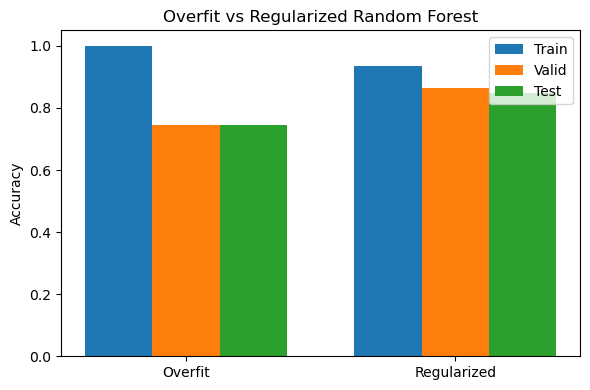

In [10]:
labels = list(df['config'])
train_vals = list(df['train_acc'])
valid_vals = list(df['valid_acc'])
test_vals = list(df['test_acc'])
x = np.arange(len(labels))
width = 0.25
plt.figure(figsize=(6,4))
plt.bar(x - width, train_vals, width, label='Train')
plt.bar(x, valid_vals, width, label='Valid')
plt.bar(x + width, test_vals, width, label='Test')
plt.xticks(x, labels)
plt.ylabel('Accuracy')
plt.title('Overfit vs Regularized Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

### Step 3. Validation Curve over `max_depth`

To further investigate model capacity, max_depth is varied while all other hyperparameters are held constant (with bootstrapping and feature subsampling enabled). The resulting plot shows that training accuracy rapidly approaches 1.0 as tree depth increases, whereas validation and test accuracies plateau and may decline, thereby illustrating the bias–variance tradeoff.

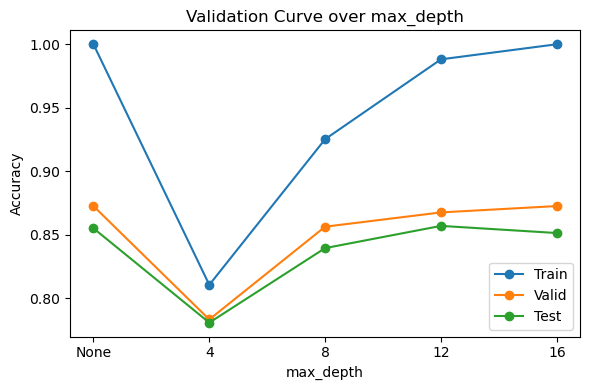

In [11]:
depths = [None, 4, 8, 12, 16]
depth_rows = []
for d in depths:
    params = dict(bootstrap=True, max_features='sqrt', max_depth=d, min_samples_leaf=1, n_estimators=200)
    metrics = run_rf(params, X_tr, y_tr, X_va, y_va, X_te, y_te)
    metrics['max_depth'] = d
    depth_rows.append(metrics)

df_depth = pd.DataFrame(depth_rows)
plt.figure(figsize=(6,4))
plt.plot([str(d) for d in depths], df_depth['train_acc'], marker='o', label='Train')
plt.plot([str(d) for d in depths], df_depth['valid_acc'], marker='o', label='Valid')
plt.plot([str(d) for d in depths], df_depth['test_acc'], marker='o', label='Test')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Validation Curve over max_depth')
plt.legend()
plt.tight_layout()
plt.show()

### Step 4. OOB Accuracy vs. Test Accuracy

Out-of-bag (OOB) estimates are used to assess predictive performance by evaluating each tree on the samples omitted from its corresponding bootstrap draw. This approach provides an internal, cross-validation–like estimate without requiring a separate validation set. In this analysis, the OOB accuracy is compared with the held-out test accuracy across the range of `max_depth` values examined above to confirm that the OOB metric serves as a reliable proxy for generalization performance.

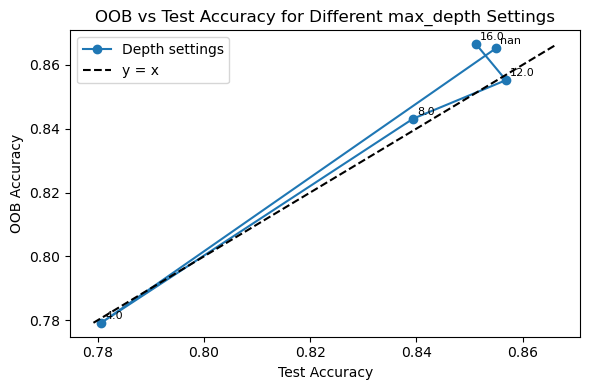

In [12]:
# NOTE: Concept and visualization style adapted from MachineLearning_ensemble_trees.ipynb
# Compare OOB accuracy vs Test accuracy across tree depths
plt.figure(figsize=(6,4))

# Filter out any depths where OOB was not computed (should not happen here)
oob_acc = df_depth['oob_score']
test_acc = df_depth['test_acc']

plt.plot(test_acc, oob_acc, 'o-', label='Depth settings')
# 1:1 reference line
min_val = min(test_acc.min(), oob_acc.min())
max_val = max(test_acc.max(), oob_acc.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='y = x')

for d, x, y in zip(df_depth['max_depth'], test_acc, oob_acc):
    plt.annotate(str(d), (x, y), textcoords='offset points', xytext=(3,3), fontsize=8)

plt.xlabel('Test Accuracy')
plt.ylabel('OOB Accuracy')
plt.title('OOB vs Test Accuracy for Different max_depth Settings')
plt.legend()
plt.tight_layout()
plt.show()

### Results and Interpretation

- In the overfit configuration, the Random Forest achieves near-perfect training accuracy but noticeably lower validation and test accuracies. This behavior confirms that deep, highly correlated trees can memorize noisy training labels and fail to generalize.
- The regularized configuration yields a much smaller gap between training and test performance, with higher overall generalization accuracy. Bootstrapping and feature subsampling reduce tree correlation, while limiting depth and enforcing a minimum leaf size control model complexity.
- The validation curve over `max_depth` shows that increasing depth initially improves performance by reducing bias, but beyond a certain point, test accuracy stops improving and may slightly deteriorate. This is a clear manifestation of the bias–variance tradeoff.

Overall, these experiments demonstrate that Random Forests are not immune to overfitting. Properly tuning hyperparameters related to tree depth, leaf size, and randomization is essential for robust performance.

### About the Author

**Sujin Park** is a Ph.D. student in the Maseeh Department of Civil, Architectural and Environmental Engineering at The University of Texas at Austin. Her research interests include subsurface environmental remediation, colloidal transport in porous media, and the application of machine learning methods to subsurface datasets.

Feel free to contact me about this workflow, or my research topic of interest.

Sincerely,<br>
*Meshack Nyiti*

___________________

### Work Supervised by:

#### Michael Pyrcz, Associate Professor, University of Texas at Austin 
*Novel Data Analytics, Geostatistics and Machine Learning Subsurface Solutions*

With over 17 years of experience in subsurface consulting, research and development, Michael has returned to academia driven by his passion for teaching and enthusiasm for enhancing engineers' and geoscientists' impact in subsurface resource development. 

For more about Michael check out these links:

#### [Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)